## Fetch and Display NYSE Stock Data

### yfinance module
nyse 종목

In [1]:
# _tsa_00.py
# nyse stock

# 코랩 추가.
!pip install yfinance

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf                       ## NYSE 데이터 모듈
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭.
from statsmodels.tsa.ar_model import AutoReg


### Tickers and close prices

In [2]:
# import pandas as pd
# import yfinance as yf

# 종목 리스트 한 번에 가져오는 아이디어.
# 1. 나스닥 주요 상위 종목 티커 리스트
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "META",
           "GOOGL", "TSLA", "AVGO", "COST", "NFLX",
           "SKHY", "MU", "AMD", "ASML", "TSM",
           "INTC"]
stock_data = []

# 2. 각 종목의 세부 정보 가져오기
for tckr in tickers:
    stock = yf.Ticker(tckr)
    info = stock.info

    stock_data.append({
        "티커": tckr,
        "기업명": info.get("longName", "N/A"),
        "섹터": info.get("sector", "N/A"),
        "현재가($)": info.get("currentPrice", "N/A"),
        "시가총액($)": f"{info.get('marketCap', 0):,}"
    })

# 3. 데이터프레임 변환 및 출력
df_tckr = pd.DataFrame(stock_data)
print(df_tckr)

# 티커에 대한 가격, 볼륨 데이터, k 년 자료 가져오기
df_dat = yf.download(tickers, period='1y', auto_adjust=True)
df_dat.info()   # ticker마다 close, open, volume 등

# 다운 자료 중 종가 추출
df_dat_cls = df_dat['Close'].copy()
df_dat_cls

       티커                                                기업명  \
0    AAPL                                         Apple Inc.   
1    MSFT                              Microsoft Corporation   
2    NVDA                                 NVIDIA Corporation   
3    AMZN                                   Amazon.com, Inc.   
4    META                               Meta Platforms, Inc.   
5   GOOGL                                      Alphabet Inc.   
6    TSLA                                        Tesla, Inc.   
7    AVGO                                      Broadcom Inc.   
8    COST                       Costco Wholesale Corporation   
9    NFLX                                      Netflix, Inc.   
10   SKHY                                      SK hynix Inc.   
11     MU                            Micron Technology, Inc.   
12    AMD                       Advanced Micro Devices, Inc.   
13   ASML                                  ASML Holding N.V.   
14    TSM  Taiwan Semiconductor Manufact

[                       0%                       ]

[******                12%                       ]  2 of 16 completed

[*********             19%                       ]  3 of 16 completed

[************          25%                       ]  4 of 16 completed

...

[**********************88%*****************      ]  14 of 16 completed

[**********************94%********************   ]  15 of 16 completed

[*********************100%***********************]  16 of 16 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-10-10 to 2026-10-09
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    251 non-null    float64
 1   (Close, AMD)     251 non-null    float64
 2   (Close, AMZN)    251 non-null    float64
 3   (Close, ASML)    251 non-null    float64
 4   (Close, AVGO)    251 non-null    float64
 5   (Close, COST)    251 non-null    float64
 6   (Close, GOOGL)   251 non-null    float64
 7   (Close, INTC)    251 non-null    float64
 8   (Close, META)    251 non-null    float64
 9   (Close, MSFT)    251 non-null    float64
 10  (Close, MU)      251 non-null    float64
 11  (Close, NFLX)    251 non-null    float64
 12  (Close, NVDA)    251 non-null    float64
 13  (Close, SKHY)    65 non-null     float64
 14  (Close, TSLA)    251 non-null    float64
 15  (Close, TSM)     251 non-null    float64
 16  (High, AAPL)     251 non-null    float64
 1

Ticker,AAPL,AMD,AMZN,ASML,AVGO,COST,GOOGL,INTC,META,MSFT,MU,NFLX,NVDA,SKHY,TSLA,TSM
Date,,,,,,,,,,,,,,,,
2025-10-10,244.367310,214.899994,216.369995,930.064026,322.234070,924.615356,235.956360,36.369999,702.915649,506.790283,181.422546,122.008003,182.722229,NaN,413.489990,277.720703
2025-10-13,246.748520,216.419998,220.070007,978.216858,354.067413,930.133057,243.516693,37.220001,713.280518,509.855072,192.581619,121.903000,187.869904,NaN,435.899994,299.717896
2025-10-14,246.858124,218.089996,216.389999,976.746521,341.590179,941.019592,244.813324,35.630001,706.254395,509.378998,186.877197,121.535004,179.599716,NaN,429.239990,292.840668
2025-10-15,248.422318,238.600006,215.570007,1003.202332,348.737030,949.450378,250.378845,37.150002,715.124207,509.240143,191.752441,120.329002,179.400177,NaN,435.149994,301.518829
2025-10-16,246.539291,234.559998,214.470001,1012.918335,351.536224,920.250671,250.807724,36.840000,709.662781,507.434998,202.332077,118.359001,181.375458,NaN,428.750000,296.699829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-05,332.890015,631.750000,251.399994,1859.859985,362.510010,923.520020,346.470001,116.190002,741.900024,525.179993,1063.959961,67.500000,238.899994,195.020004,378.730011,485.799988
2026-10-06,333.630005,649.419983,256.290009,1834.099976,375.809998,935.679993,347.679993,112.500000,738.880005,529.299988,1045.560059,68.690002,239.240005,182.559998,380.679993,482.299988
2026-10-07,336.670013,645.859985,259.920013,1804.959961,376.510010,942.250000,350.500000,113.120003,721.309998,529.760010,1088.000000,69.699997,237.470001,178.250000,377.809998,472.200012


### subplots, line chart, prices, returns

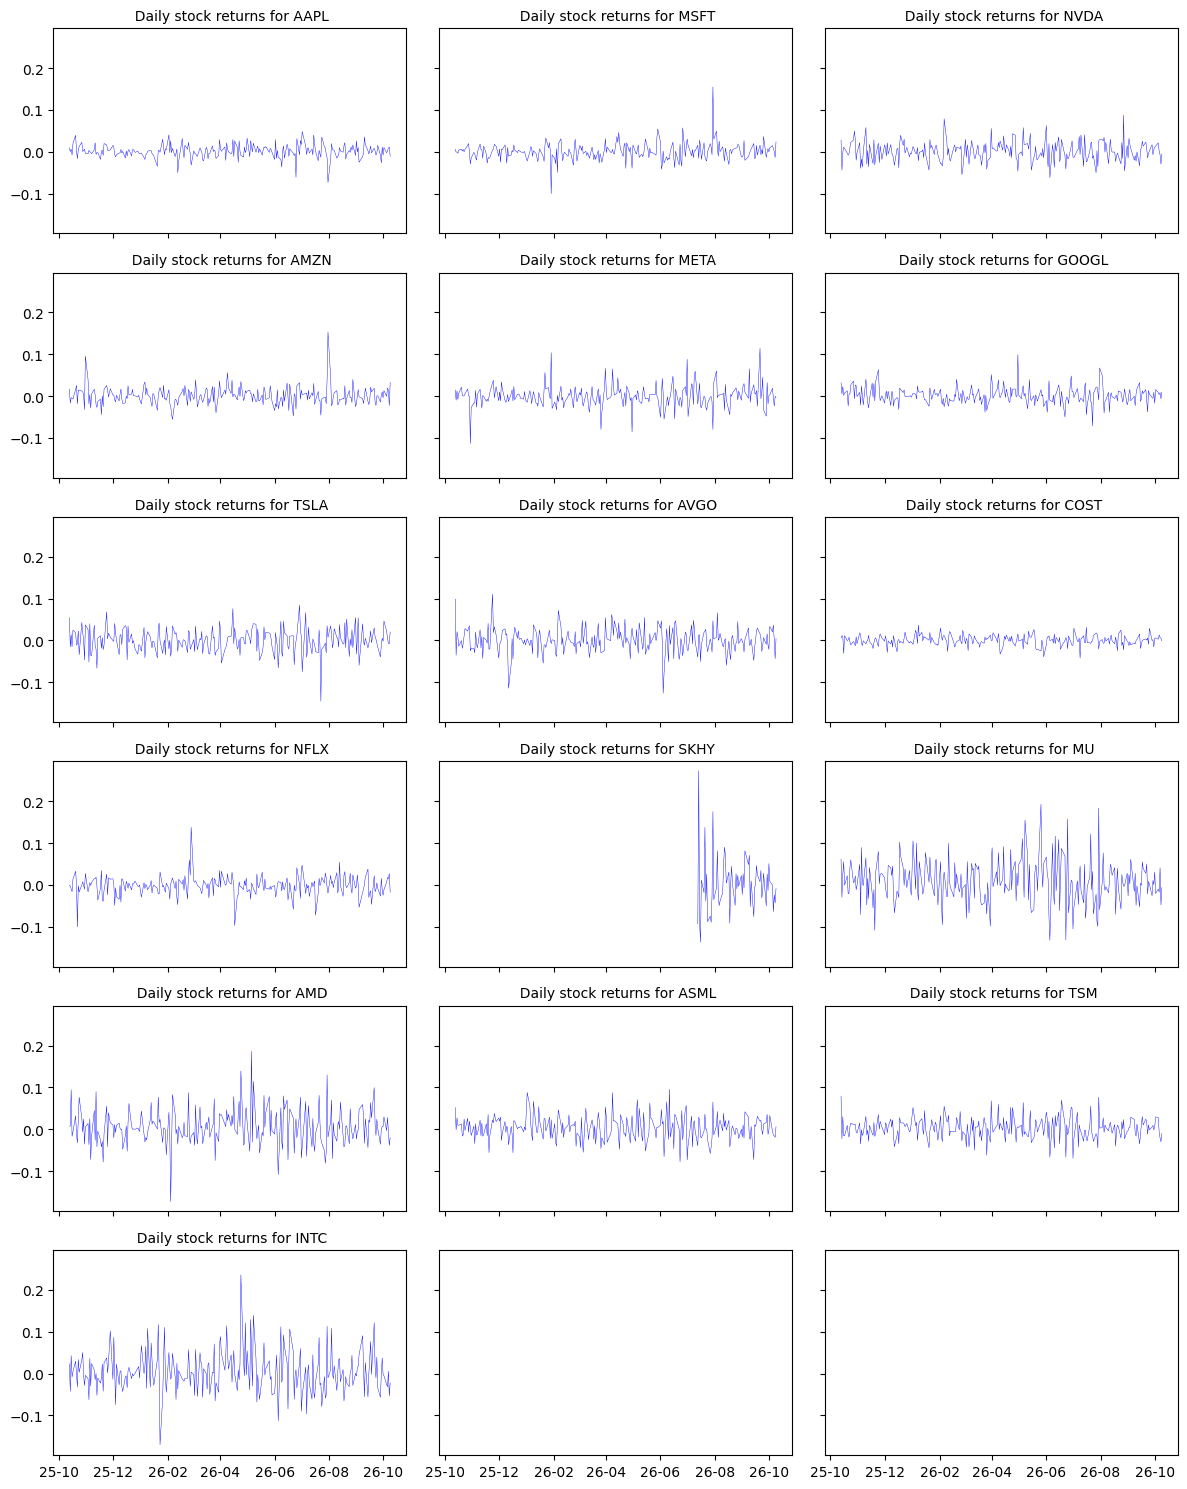

In [3]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

n_plot = len(tickers)
sub_c = 3
sub_r = int(np.ceil(n_plot/sub_c))

fig, axes = plt.subplots(sub_r, sub_c,
                         figsize=(sub_c*4, sub_r*2.5),
                         sharex=True,
                         sharey=True
                         )

for ax, ticker in zip(axes.flat, tickers) :
  ax.plot(yymmdd,
          df_dat_cls[ticker].pct_change(fill_method=None),
          color='blue',
          linewidth=0.3
          )  # 여기 ticker는 이미 "AAPL"처럼 인식, 앞에서.
  ax.set_title(f"  Daily stock returns for {ticker} ", fontsize=10)
  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.tight_layout()
plt.show()

### subplots, histograms, daily returns

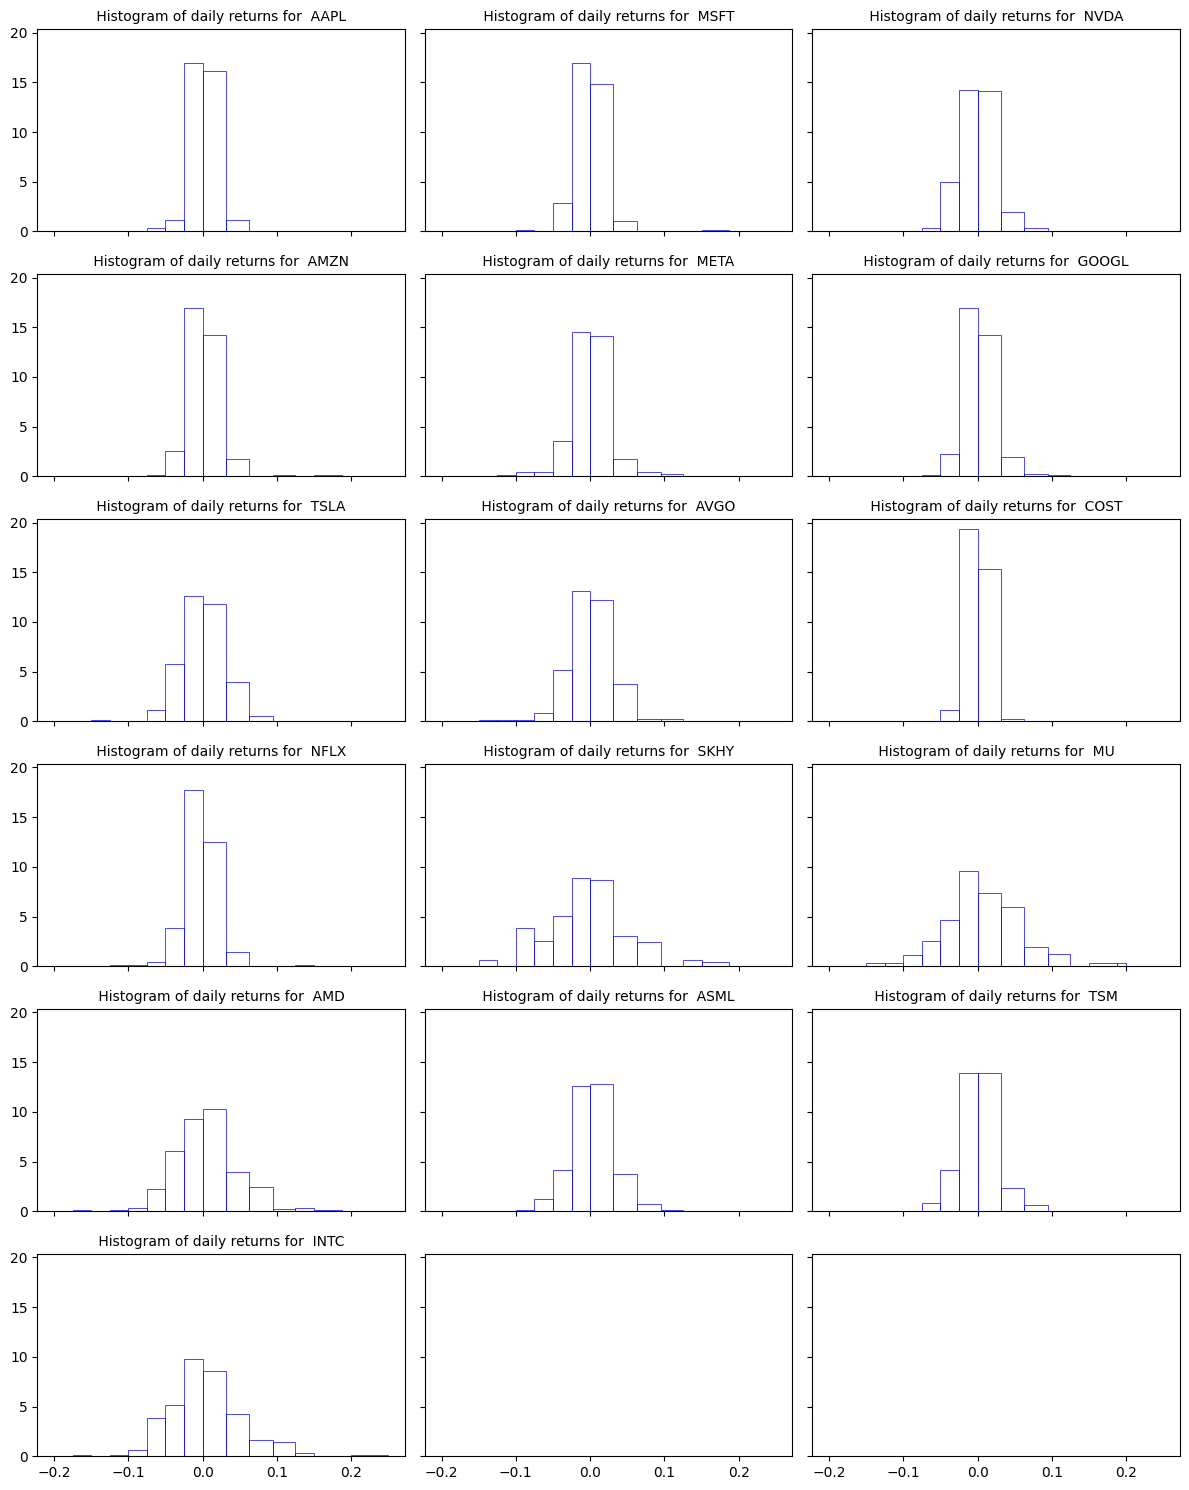

In [4]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
#yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
#yymmdd = pd.to_datetime( yymmdd )

n_plot = len(tickers)
sub_c = 3
sub_r = int(np.ceil(n_plot/sub_c))

b_class = [-0.2, -0.175, -0.15, -0.125, -0.1, -0.075, -0.05,-0.025, 0.0, 0.03125, 0.0625, 0.095, 0.125, 0.15, 0.1875, 0.2, 0.25]

fig, axes = plt.subplots(sub_r, sub_c,
                         figsize=(sub_c*4, sub_r*2.5),
                         sharex=True,
                         sharey=True
                         )
for ax, ticker in zip(axes.flat, tickers) :
  ax.hist(df_dat_cls[ticker].pct_change(fill_method=None), # 여기 ticker는 이미 "AAPL"처럼 인식, 앞에서.
          color='blue',
          linewidth=0.5,
          bins = b_class,       # 11처럼 갯수로 지정, 혹은 계급 구간 제시,
          facecolor='None',
          edgecolor='blue',
          density=True
          )
  ax.set_title(f" Histogram of daily returns for  {ticker} ", fontsize=10)
plt.tight_layout()
plt.show()

### two tickers, prices
뭔가 간단하게

In [5]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

tic_1 = 'NFLX'
tic_2 = 'GOOGL'
stck_prc_1= df_dat_cls[tic_1]
stck_prc_2 = df_dat_cls[tic_2]


#### daily stock returns

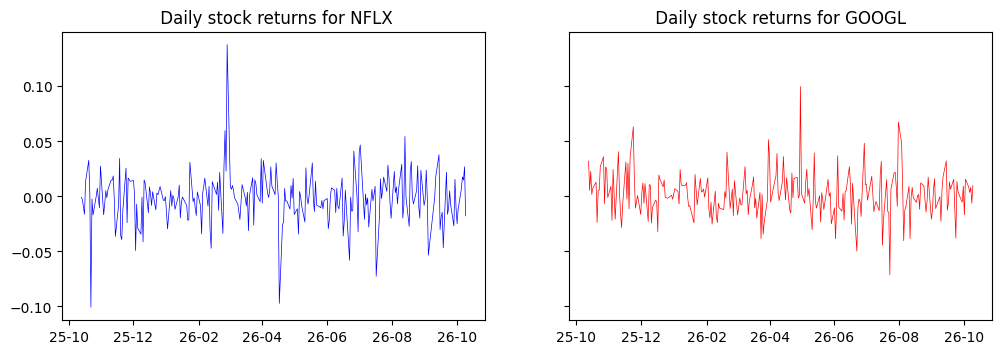

In [6]:
# 나란히 차트 2개. 1행, 2열.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16*0.75, 10*0.75/2), sharex=True, sharey=True )
axes[0].plot(yymmdd, stck_prc_1.pct_change(fill_method=None), color='blue', linewidth=0.5)
axes[1].plot(yymmdd, stck_prc_2.pct_change(fill_method=None), color='red', linewidth=0.5)

axes[0].set_title(f" Daily stock returns for {tic_1}")
axes[1].set_title(f" Daily stock returns for {tic_2} ")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))


#### distibutions in one chart

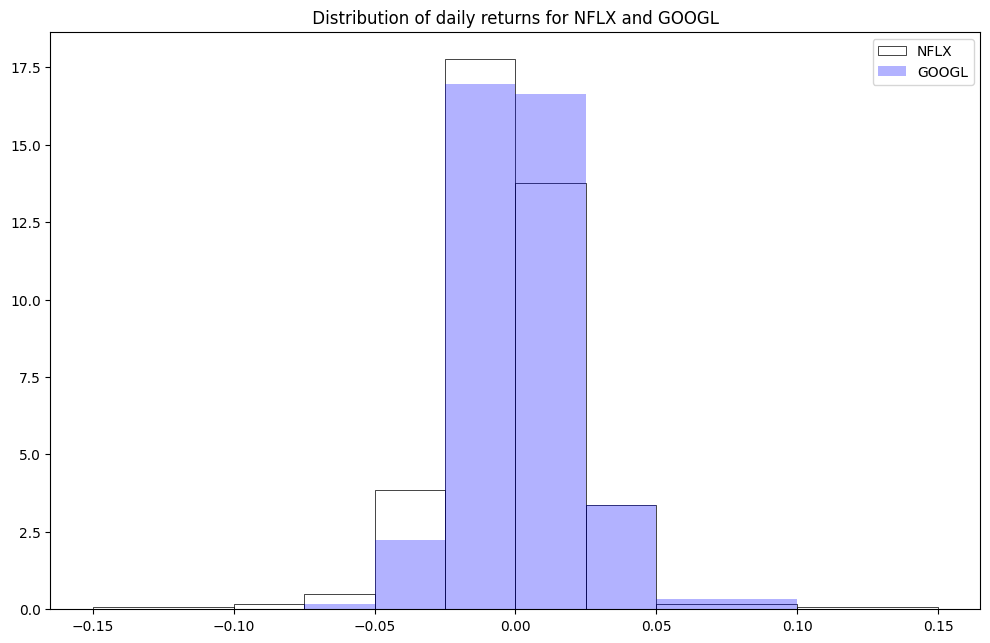

In [7]:
# 차트 여러 개, 화면 1개.
b_class = [-0.15, -0.1, -0.075, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.15 ]
plt.figure(figsize=(12, 7.5))
plt.hist(stck_prc_1.pct_change(fill_method=None),
         color='blue',
         linewidth=0.51,
         bins = b_class, # 11,
         facecolor='None',
         edgecolor='black',
         density=True,
         label = f"{tic_1}"
         )
plt.hist(stck_prc_2.pct_change(fill_method=None),
         color='blue',
         linewidth=1,
         bins = b_class, # 11,
         facecolor='blue',
         edgecolor='None',
         density=True,
         #linestyle='--'
         label = f"{tic_2}",
         alpha = 0.3
         )
plt.title(f" Distribution of daily returns for {tic_1} and {tic_2} ")
plt.legend()
plt.show()